In [1]:
!pip -q install -U transformers accelerate peft datasets sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.7 MB/s eta 0:00:00


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


In [3]:
# %pip install -U transformers peft trl datasets accelerate pymupdf pillow


In [4]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Base model (not Instruct) -> no chat template, no "Assistant:" wrapper.
# We prompt it directly as: "<image>" + instruction, then the target text.
model_id = "HuggingFaceTB/SmolVLM-500M-Base"

processor = AutoProcessor.from_pretrained(model_id)

processor.image_processor.do_image_splitting = False
processor.image_processor.size = {
    "height": 512,
    "width": 512,
}

# Make sure padding is added on the right so the prompt always starts at
# position 0 -> lets us mask the prompt for the loss with a fixed offset.
processor.tokenizer.padding_side = "right"
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
)

model.to(device)

print("✅ Base model + Processor loaded successfully!")


Using device: cuda


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/424 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.28k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✅ Base model + Processor loaded successfully!


In [5]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [6]:
from peft import LoraConfig, get_peft_model, TaskType


lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules="all-linear",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

model.gradient_checkpointing_enable()

model.print_trainable_parameters()

trainable params: 11,549,696 || all params: 519,032,000 || trainable%: 2.2252


In [7]:
from datasets import load_dataset

# NOTE: 500 samples total was likely too few for the model to learn general
# document layout/structure. Bumped up, and (important fix) we now hold out a
# real test split so "after fine-tuning" metrics aren't measured on data the
# model was trained on.
NUM_SAMPLES = 500
TEST_SIZE = 50

# Load dataset
dataset = load_dataset("v1v1d/v1v1d_docmatix_test_v1_fast")

subset = dataset["train"].select(range(NUM_SAMPLES))
split = subset.train_test_split(test_size=TEST_SIZE, seed=42)

train_dataset = split["train"]
test_dataset = split["test"]

print(train_dataset)
print(test_dataset)
print(f"Train samples: {len(train_dataset)}")
print(f"Held-out test samples: {len(test_dataset)}")


README.md:   0%|          | 0.00/1.93k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  368MB            

data/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  358MB            

data/train-00001-of-00004.parquet: downloading bytes:           |  0.00B            

...

data/train-00002-of-00004.parquet: downloading bytes:           |  0.00B            

data/train-00003-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  372MB            

data/train-00003-of-00004.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'image', 'pdf_name', 'page_number', 'page_size', 'layout', 'content_list', 'middle', 'model', 'markdown', 'html', 'html_with_coordinates', 'html_compact', 'raw_md', 'lines', 'images', 'equations', 'tables', 'pdf_info', 'vqa'],
    num_rows: 450
})
Dataset({
    features: ['id', 'image', 'pdf_name', 'page_number', 'page_size', 'layout', 'content_list', 'middle', 'model', 'markdown', 'html', 'html_with_coordinates', 'html_compact', 'raw_md', 'lines', 'images', 'equations', 'tables', 'pdf_info', 'vqa'],
    num_rows: 50
})
Train samples: 450
Held-out test samples: 50


In [8]:
sample = train_dataset[0]

print(sample.keys())
print("-" * 50)
print("PDF:", sample["pdf_name"])
print("Page:", sample["page_number"])
print("-" * 50)
print(sample["markdown"][:500])

dict_keys(['id', 'image', 'pdf_name', 'page_number', 'page_size', 'layout', 'content_list', 'middle', 'model', 'markdown', 'html', 'html_with_coordinates', 'html_compact', 'raw_md', 'lines', 'images', 'equations', 'tables', 'pdf_info', 'vqa'])
--------------------------------------------------
PDF: 00035
Page: 9
--------------------------------------------------
# Foodmax Chain LT

Food grade oil for the lubrication of drive and conveyor chains in low temperature applications

# Benefits

# Description

Foodmax Chain LT is based on a blend of synthetic hydrocarbons and is inhibited against oxidation to give a long wet film life overwidetemperatures. Foodmax Chain LT is designed for the lubricationofconveyorchainsand bearingsrunning continuously at low temperatures, down to minimum of - $40^{\circ}C$ and on chains that are moving slowly.

- Penetrates to


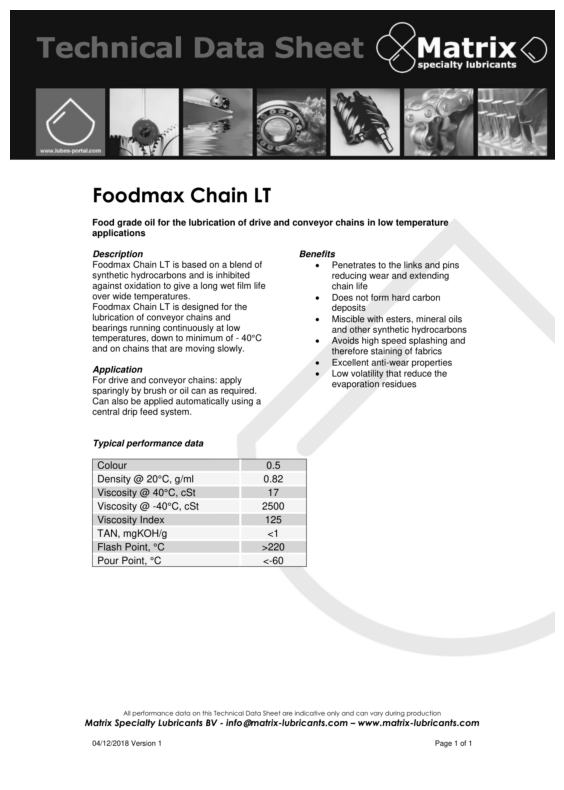

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.imshow(sample["image"])
plt.axis("off")
plt.show()

In [10]:
IGNORE_INDEX = -100

# Fixed instruction used for every sample (no chat roles, no "Assistant:" tag -
# this is a base LM, so we just teach it: image -> markdown continuation).
PROMPT_TEXT = "<image>Transcribe the content of this image to Markdown exactly as it is.\n"

# Precompute how many tokens PROMPT_TEXT expands to once it goes through the
# processor together with an image (the "<image>" placeholder gets expanded
# into a fixed number of image tokens). Since do_image_splitting=False and the
# image size is fixed at 512x512, this length is constant across all samples.
_probe = processor(
    text=[PROMPT_TEXT],
    images=[train_dataset[0]["image"]],
    return_tensors="pt",
)
PROMPT_LEN = _probe["input_ids"].shape[1]
print(f"Prompt (image + instruction) expands to {PROMPT_LEN} tokens")


def collate_fn(examples):

    texts = []
    images = []

    for example in examples:
        full_text = PROMPT_TEXT + example["markdown"] + processor.tokenizer.eos_token
        texts.append(full_text)
        images.append(example["image"])

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        # NOTE: truncation=True is kept here only for parity with the
        # original notebook, but no explicit max_length is set (same as
        # before) - this tokenizer's default max length is effectively
        # unbounded, so truncation never actually fires. DO NOT set an
        # explicit max_length here: when truncation genuinely kicks in with
        # images, it hits a bug in the Idefics3/SmolVLM processor
        # (TypeError: unsupported operand type(s) for -: 'NoneType' and
        # 'NoneType', in image_seq_lens computation) because it can no
        # longer correctly locate the image token boundaries. If you need to
        # cap sequence length, filter/drop long examples from the dataset
        # *before* training instead of truncating inside the collator.
        truncation=True,
        return_tensors="pt",
    )

    labels = batch["input_ids"].clone()

    # Mask the prompt (image tokens + instruction) for every sample - loss is
    # only computed on the markdown continuation.
    labels[:, :PROMPT_LEN] = IGNORE_INDEX

    # FIX: pad_token_id == eos_token_id for this tokenizer (verified from the
    # trainer warning: eos_token_id=2, pad_token_id=2). Masking by ID equality
    # would therefore also erase every *real* end-of-sequence token from the
    # loss, so the model never learns when to stop generating - this was the
    # root cause of the runaway/repeating generations. Mask true padding using
    # the attention_mask instead (0 = padding), which leaves the genuine EOS
    # token (attention_mask == 1 there) visible to the loss.
    labels[batch["attention_mask"] == 0] = IGNORE_INDEX

    batch["labels"] = labels

    return batch


Prompt (image + instruction) expands to 84 tokens


In [11]:
sanity_batch = collate_fn([train_dataset[0]])
visible_labels = sanity_batch["labels"][0][sanity_batch["labels"][0] != IGNORE_INDEX]

print("Shapes:")
for k, v in sanity_batch.items():
    print(" ", k, v.shape)

print()
print("-" * 60)
print("Decoded target the model will actually be trained on:")
print(processor.tokenizer.decode(visible_labels))


Shapes:
  input_ids torch.Size([1, 500])
  attention_mask torch.Size([1, 500])
  pixel_values torch.Size([1, 1, 3, 512, 512])
  pixel_attention_mask torch.Size([1, 1, 512, 512])
  labels torch.Size([1, 500])

------------------------------------------------------------
Decoded target the model will actually be trained on:
# Foodmax Chain LT

Food grade oil for the lubrication of drive and conveyor chains in low temperature applications

# Benefits

# Description

Foodmax Chain LT is based on a blend of synthetic hydrocarbons and is inhibited against oxidation to give a long wet film life overwidetemperatures. Foodmax Chain LT is designed for the lubricationofconveyorchainsand bearingsrunning continuously at low temperatures, down to minimum of - $40^{\circ}C$ and on chains that are moving slowly.

- Penetrates to the links and pins reducing wear and extending chain life Does not form hard carbon deposits Miscible with esters,mineral oils and other synthetic hydrocarbons Avoids high spe

### 🔧 Fixes applied in this version

1. **Critical bug fixed — EOS/PAD collision in `collate_fn`:** `pad_token_id == eos_token_id` for this tokenizer (confirmed by the trainer warning: `eos_token_id=2, pad_token_id=2`). The old code masked labels by `labels == pad_token_id`, which also erased every real end-of-sequence token from the loss — the model was never trained to predict `</s>`, so it kept generating until `max_new_tokens` every time (runaway/repeating output, WER > 1). Now padding is masked using `attention_mask == 0` instead, leaving the real EOS token in the loss.
2. **`predict()` now uses the exact same decoding settings as `run_ocr()`** (repetition_penalty, forced eos_token_id), so baseline vs. after-fine-tuning numbers are a fair comparison.
3. **`eval_strategy="epoch"` + `eval_dataset`** added to `TrainingArguments`/`SFTTrainer` so you can watch eval loss during training, not just final train loss.
4. **Eval set size fixed to 30 samples everywhere** (code previously said 30 in print statements but only evaluated on 10).
5. **Added raw Levenshtein distance** (char & word level, per-sample and averaged) alongside CER/WER for a more intuitive look at how far off each prediction is.

> ⚠️ Note: an earlier version of this fix also added an explicit `max_length` to the collator, which triggered a real truncation bug in the Idefics3/SmolVLM processor (`TypeError: unsupported operand type(s) for -: 'NoneType' and 'NoneType'`) whenever a document's tokenized length actually exceeded that limit. That has been reverted — `truncation=True` is kept for parity with your original code, but no explicit `max_length` is set, so truncation never actually fires (same as your original notebook's behavior).


In [12]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./smolvlm-ocr",

    # Batch
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,

    # Training
    # NOTE: since we're starting from the BASE (non-instruction-tuned) checkpoint,
    # the model also has to learn the "User:/Assistant:" turn-taking format from
    # scratch, on top of the OCR task itself. Bumped epochs up from the
    # Instruct-model recipe to give it more room to learn both.
    num_train_epochs=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,

    # Memory
    fp16=True,
    gradient_checkpointing=True,

    # Logging & Saving
    logging_steps=10,
    save_strategy="epoch",
    save_total_limit=1,

    # FIX: track eval loss every epoch so we can see over/underfitting instead
    # of only trusting the final train_loss number.
    eval_strategy="epoch",
    per_device_eval_batch_size=2,

    report_to="none",
    remove_unused_columns=False,

    dataloader_num_workers=2,
    dataloader_pin_memory=True,
)

print("✅ TrainingArguments configured")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ TrainingArguments configured


In [13]:
!pip install -U trl transformers peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 19.2 MB/s eta 0:00:00


In [14]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,  # FIX: needed for eval_strategy="epoch" above
    processing_class=processor,
    data_collator=collate_fn,
)

print("Trainer ")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer 


In [15]:
import torch

GEN_KWARGS = dict(
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.2,
)

@torch.no_grad()
def predict(example, max_new_tokens=512):
    inputs = processor(
        text=[PROMPT_TEXT],
        images=[example["image"]],
        return_tensors="pt",
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        # FIX: same repetition_penalty + explicit eos_token_id as run_ocr(),
        # so the baseline and "after fine-tuning" evals use identical decoding
        # settings and the CER/WER comparison is apples-to-apples.
        repetition_penalty=1.2,
        eos_token_id=processor.tokenizer.eos_token_id,
    )

    # Only decode the newly generated continuation (skip the prompt tokens).
    generated = outputs[0][inputs["input_ids"].shape[1]:]

    prediction = processor.tokenizer.decode(generated, skip_special_tokens=True)

    return prediction.strip()


In [16]:
sample = train_dataset[0]

pred = predict(sample)

print("Prediction:")
print(pred)

print("\nGround Truth:")
print(sample["markdown"])

Prediction:
Technical Data Sheet Foodmax Chain LT applications and other alternative hydro-hydraulic systems can be applied automatically using a Viseviscosity Index 128000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

Ground Truth:
# Foodmax Chain LT

Food grade oil for the lubrication of drive and conveyor chains in low temperature applications

# Benefits

# Description

Foodmax Chain LT is based on a blend of synthetic hydrocarbons and is inhibited against oxidation to give a long wet film life overwidetemperatures. Foodmax Chain LT is designed for the lubri

In [17]:
# Not needed for the base model: there is no chat wrapper / "Assistant:" tag
# to strip out. predict() already returns only the generated continuation.


In [18]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.3 MB/s eta 0:00:00


In [19]:
!pip install -q python-Levenshtein


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.6 MB/s eta 0:00:00


In [20]:
# from jiwer import wer, cer

# EVAL_N = min(30, len(test_dataset))

# predictions = []
# references = []

# for example in test_dataset.select(range(EVAL_N)):

#     pred = predict(example)

#     predictions.append(pred)
#     references.append(example["markdown"])


# baseline_cer = cer(references, predictions)
# baseline_wer = wer(references, predictions)


# exact = sum(
#     p.strip() == r.strip()
#     for p, r in zip(predictions, references)
# )

# exact_match = exact / len(references)


# print(f"Baseline CER ({EVAL_N} held-out samples):", baseline_cer)
# print(f"Baseline WER ({EVAL_N} held-out samples):", baseline_wer)
# print("Baseline Exact Match:", exact_match)


Baseline CER (30 held-out samples): 1.0818165353617677
Baseline WER (30 held-out samples): 1.4692334739803095
Baseline Exact Match: 0.0


In [23]:
trainer.train()


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.830657,2.133448,1.930890,2310432.000000,0.591198
2,1.518875,2.174205,1.787317,2589942.000000,0.587683
3,1.537012,2.187992,1.815329,2869452.000000,0.588677
4,1.568496,2.230253,1.754594,3148962.000000,0.586640
5,1.716666,2.275265,1.682377,3428472.000000,0.581847
6,1.517942,2.335399,1.641815,3707982.000000,0.576615
7,1.271277,2.373594,1.611488,3987492.000000,0.574215
8,1.265088,2.386264,1.598321,4267002.000000,0.574706


TrainOutput(global_step=456, training_loss=1.5399984811481677, metrics={'train_runtime': 2660.0336, 'train_samples_per_second': 1.353, 'train_steps_per_second': 0.171, 'total_flos': 9167025308745216.0, 'train_loss': 1.5399984811481677, 'epoch': 8.0})

In [24]:
model.save_pretrained("./smolvlm-ocr-lora")
processor.save_pretrained("./smolvlm-ocr-lora")

print("./smolvlm-ocr-lora")


./smolvlm-ocr-lora


In [25]:
model.eval()

@torch.no_grad()
def run_ocr(image, max_new_tokens=512):
    inputs = processor(
        text=[PROMPT_TEXT],
        images=[image],
        return_tensors="pt",
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.2,
        eos_token_id=processor.tokenizer.eos_token_id,
    )

    generated_text = processor.tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return generated_text.strip()


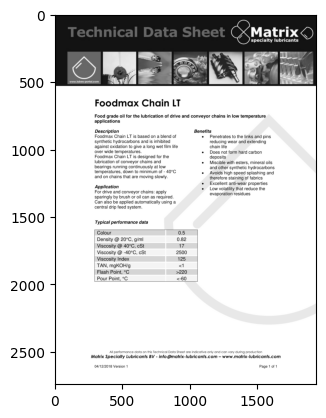

In [26]:
import matplotlib.pyplot as plt
plt.imshow( train_dataset[0]["image"])

In [27]:
sample = train_dataset[0]

sample_image = sample["image"]

prediction = run_ocr(sample_image)

ground_truth = sample["markdown"]


print("=" * 80)
print("Prediction:")
print(prediction)

print("\n" + "=" * 80)

print("Ground Truth:")
print(ground_truth)

Prediction:
# Foodmax Chain LT

Food grade oil for drive and conveyor chains in low temperature applications

<table><tr><td>Description</td></tr><tr><td>Benefits</td></tr><tr><td>To differentiate links between pins, chins are coated with a thin layer of polyvinylidene fluoride (PVDF) that inhibits oxidation against attack by oxygen and other chemicals. The PVDF also provides mechanical stability at temperatures below 10°C.</td></tr><tr><td>Costs</td></tr><tr><td>The cost per link is $5\%$ lower than conventional chain materials such as steel or rubber.</td></tr><tr><td>Sustainability</td></tr><tr><td>The use of PVDF reduces environmental impact: no chlorine, no heavy metals.</td></tr><tr><td>Easeofuse</td></tr><tr><td>The coating prevents the formation of free radicals which can cause degradation of the chain over time.</td></tr><tr><td>Resistance to abrasion</td></tr><tr><td>The chain is resistant to wear and scuffing under high speeds.</td></tr><tr><td>Typical performance curves</td

In [28]:
EVAL_N = min(30, len(test_dataset))
eval_dataset = test_dataset.select(range(EVAL_N))


In [ ]:
# Not needed either - run_ocr() already returns just the generated markdown.


In [29]:
from jiwer import wer, cer
import Levenshtein

predictions = []
references = []

for example in eval_dataset:

    pred = run_ocr(example["image"])

    predictions.append(pred)
    references.append(example["markdown"])


after_cer = cer(references, predictions)
after_wer = wer(references, predictions)

exact = sum(
    p.strip() == r.strip()
    for p, r in zip(predictions, references)
)

after_exact_match = exact / len(references)

# Raw Levenshtein distance (char-level and word-level), per sample and averaged.
# CER/WER are just this distance normalized by reference length, so this gives
# the same signal in absolute "number of edits" terms, which is often more
# intuitive for spotting samples where the model went completely off the rails.
char_dists = [Levenshtein.distance(p, r) for p, r in zip(predictions, references)]
word_dists = [Levenshtein.distance(p.split(), r.split()) for p, r in zip(predictions, references)]

print(f"After Fine-Tuning CER ({len(eval_dataset)} held-out samples):", after_cer)
print(f"After Fine-Tuning WER ({len(eval_dataset)} held-out samples):", after_wer)
print("After Fine-Tuning Exact Match:", after_exact_match)
print()
print(f"Avg char-level Levenshtein distance: {sum(char_dists)/len(char_dists):.1f}")
print(f"Avg word-level Levenshtein distance: {sum(word_dists)/len(word_dists):.1f}")
print()
print("Per-sample char-level Levenshtein distance:", char_dists)
print("Per-sample word-level Levenshtein distance:", word_dists)


After Fine-Tuning CER (30 held-out samples): 0.7983877635386524
After Fine-Tuning WER (30 held-out samples): 0.9706393328700487
After Fine-Tuning Exact Match: 0.03333333333333333

Avg char-level Levenshtein distance: 1288.1
Avg word-level Levenshtein distance: 186.2

Per-sample char-level Levenshtein distance: [473, 74, 1914, 192, 1828, 2322, 275, 1998, 89, 974, 939, 5638, 919, 944, 1014, 1600, 619, 795, 337, 532, 1810, 1290, 2413, 1501, 1363, 1258, 0, 2078, 1884, 1571]
Per-sample word-level Levenshtein distance: [38, 20, 32, 37, 356, 415, 52, 383, 10, 172, 146, 1003, 12, 75, 184, 250, 88, 132, 67, 87, 105, 121, 508, 261, 227, 73, 0, 80, 380, 273]


In [1]:
!pip install -q pymupdf

ERROR: Operation cancelled by user


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import fitz  # pymupdf
import os

pdf_path = "1_README.pdf"
output_folder = "pages"
os.makedirs(output_folder, exist_ok=True)

doc = fitz.open(pdf_path)
page_paths = []

for page_number in range(len(doc)):
    page = doc[page_number]
    pix = page.get_pixmap(dpi=300)
    image_path = os.path.join(output_folder, f"page_{page_number + 1}.png")
    pix.save(image_path)
    page_paths.append(image_path)
    print(f"Saved: {image_path}")

doc.close()


In [ ]:
from PIL import Image

markdown_content = ""

for image_path in page_paths:
    print(f"Processing {image_path} ...")
    image = Image.open(image_path).convert("RGB")
    page_markdown = run_ocr(image)
    markdown_content += f"\n\n<!-- {image_path} -->\n\n" + page_markdown

output_file = "document_finetuned.md"
with open(output_file, "w", encoding="utf-8") as f:
    f.write(markdown_content)

print("\nDone! Saved:", output_file)
print("=" * 80)
print(markdown_content)
